In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [36]:
titanic = sns.load_dataset("titanic")

In [37]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [38]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [39]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [40]:
features = ["pclass", "sex", "fare", "embarked", "age"]

target = ["survived"]

In [41]:
# Filling the missing values
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [42]:
# ENCODING

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [43]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [44]:
X = titanic[features]

y = titanic[target]

In [45]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [46]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [49]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


# DECISION TREE MODEL - NO PRONING 

In [50]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [51]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, y_pred))

Accuracy Score:  0.7653631284916201


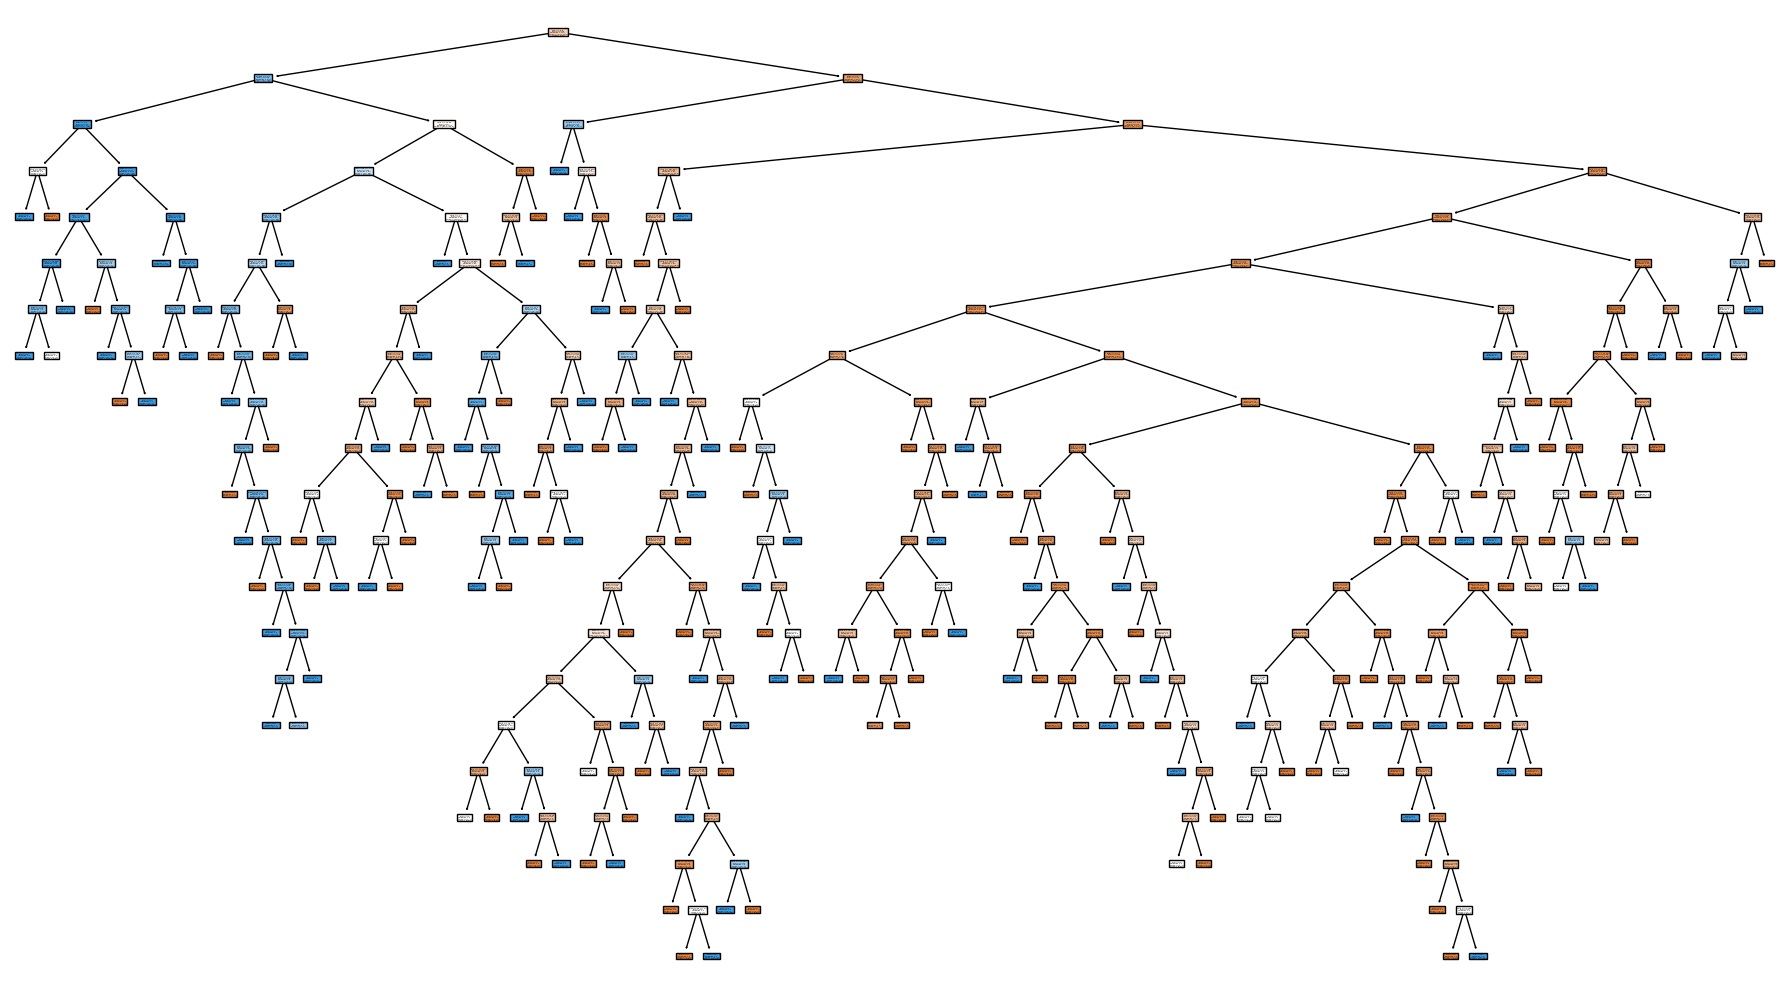

In [52]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

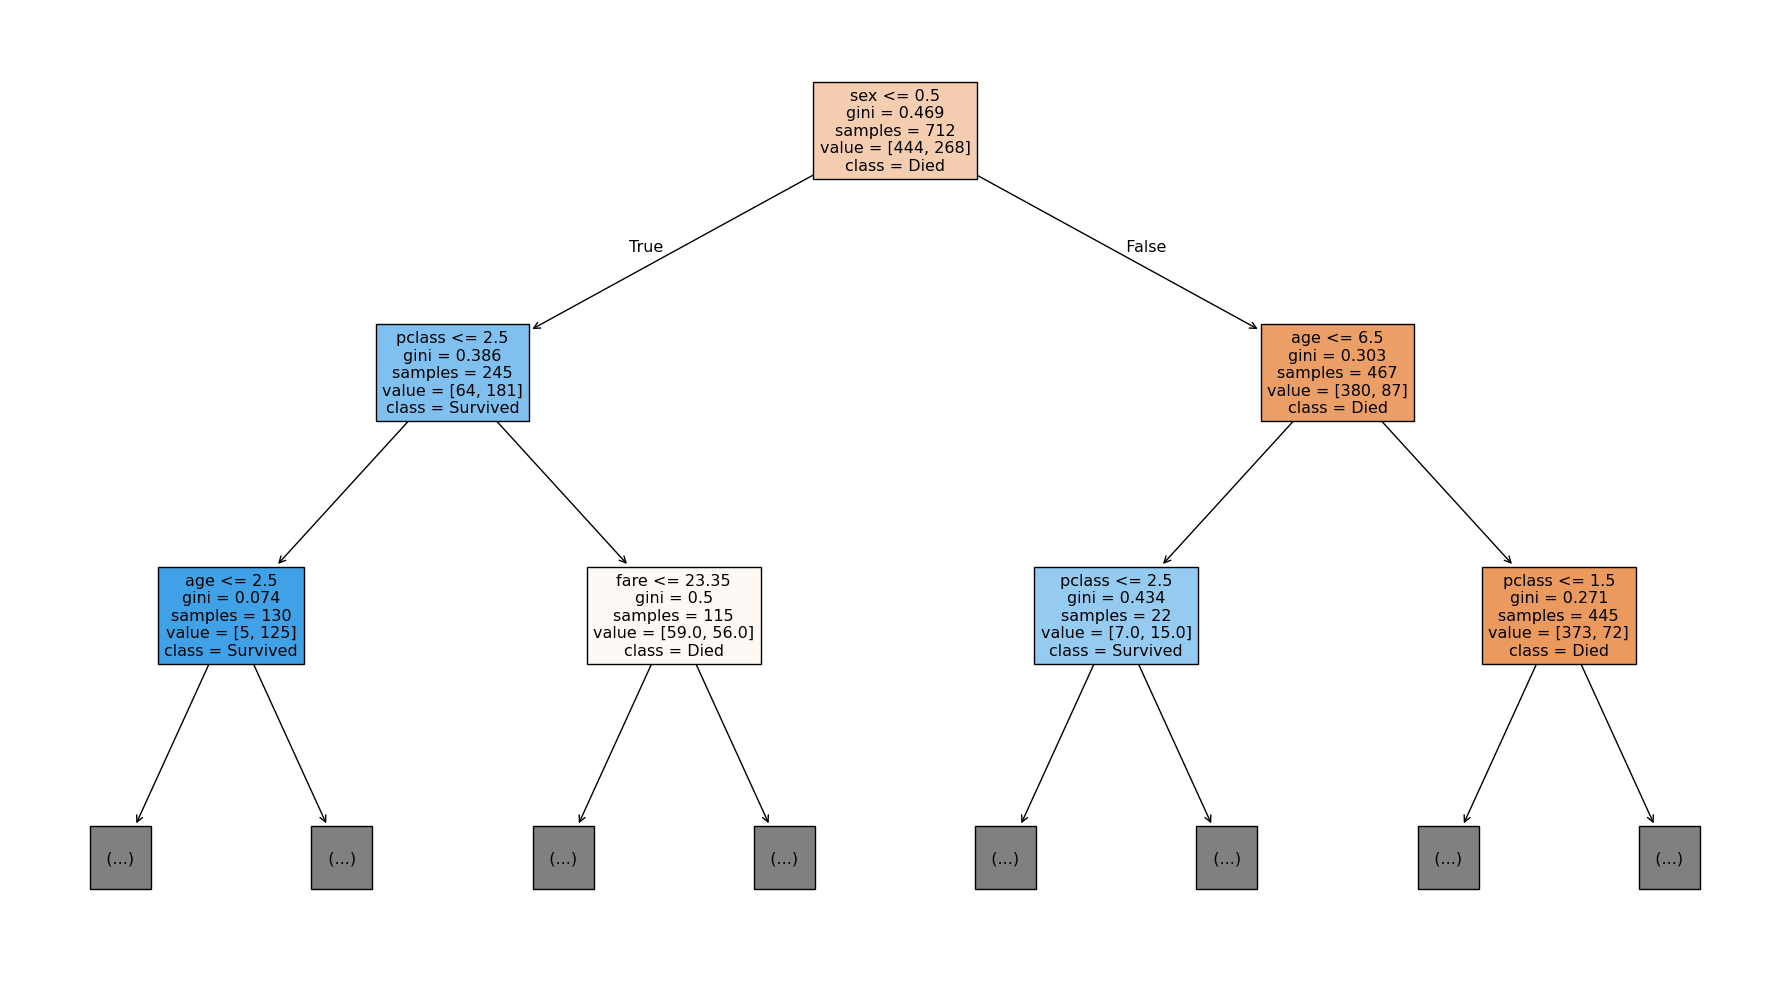

In [53]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

# DECISION TREE MODEL: PRE-PRONING 

In [54]:
max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"For Depth = {depth}, Accuracy = {acc}")

For Depth = 2, Accuracy = 0.7653631284916201
For Depth = 3, Accuracy = 0.7988826815642458
For Depth = 4, Accuracy = 0.7988826815642458
For Depth = 5, Accuracy = 0.7988826815642458
For Depth = 6, Accuracy = 0.7988826815642458
For Depth = 7, Accuracy = 0.7932960893854749
For Depth = 8, Accuracy = 0.7988826815642458
For Depth = 9, Accuracy = 0.7821229050279329
For Depth = 10, Accuracy = 0.7877094972067039


In [55]:
min_samples_split = [10, 15, 20, 25, 30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=9, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"For Min Sample Split = {split}, Accuracy = {acc}")

For Min Sample Split = 10, Accuracy = 0.8324022346368715
For Min Sample Split = 15, Accuracy = 0.8379888268156425
For Min Sample Split = 20, Accuracy = 0.8379888268156425
For Min Sample Split = 25, Accuracy = 0.8212290502793296
For Min Sample Split = 30, Accuracy = 0.8100558659217877


For Depth = 2, Accuracy = 0.7653631284916201
For Depth = 3, Accuracy = 0.7988826815642458
For Depth = 4, Accuracy = 0.7988826815642458


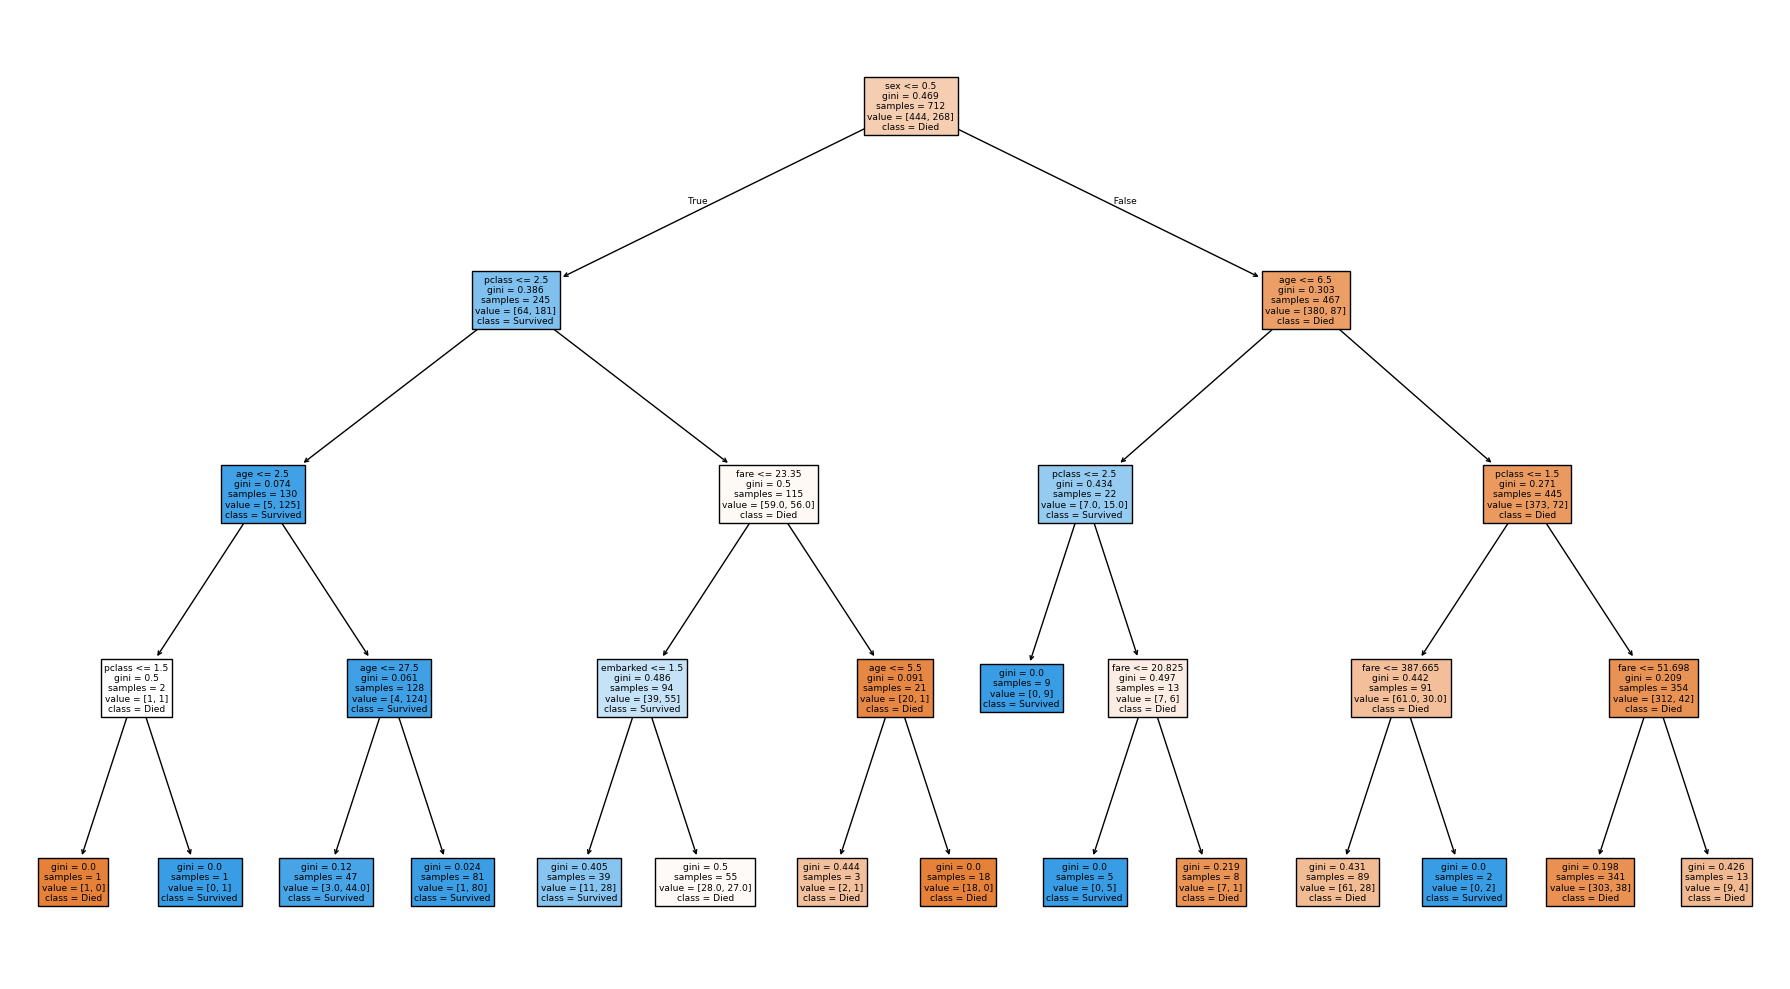

For Depth = 5, Accuracy = 0.7988826815642458
For Depth = 6, Accuracy = 0.7988826815642458
For Depth = 7, Accuracy = 0.7988826815642458
For Depth = 8, Accuracy = 0.7877094972067039
For Depth = 9, Accuracy = 0.7988826815642458
For Depth = 10, Accuracy = 0.8044692737430168


In [59]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)   # FIXED
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"For Depth = {depth}, Accuracy = {acc}")

    # Plot only for depth = 9
    if depth == 4:
        plt.figure(figsize=(18, 10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )

        plt.tight_layout()
        plt.show()


For Min Sample Split = 10, Accuracy = 0.7988826815642458
For Min Sample Split = 15, Accuracy = 0.7988826815642458


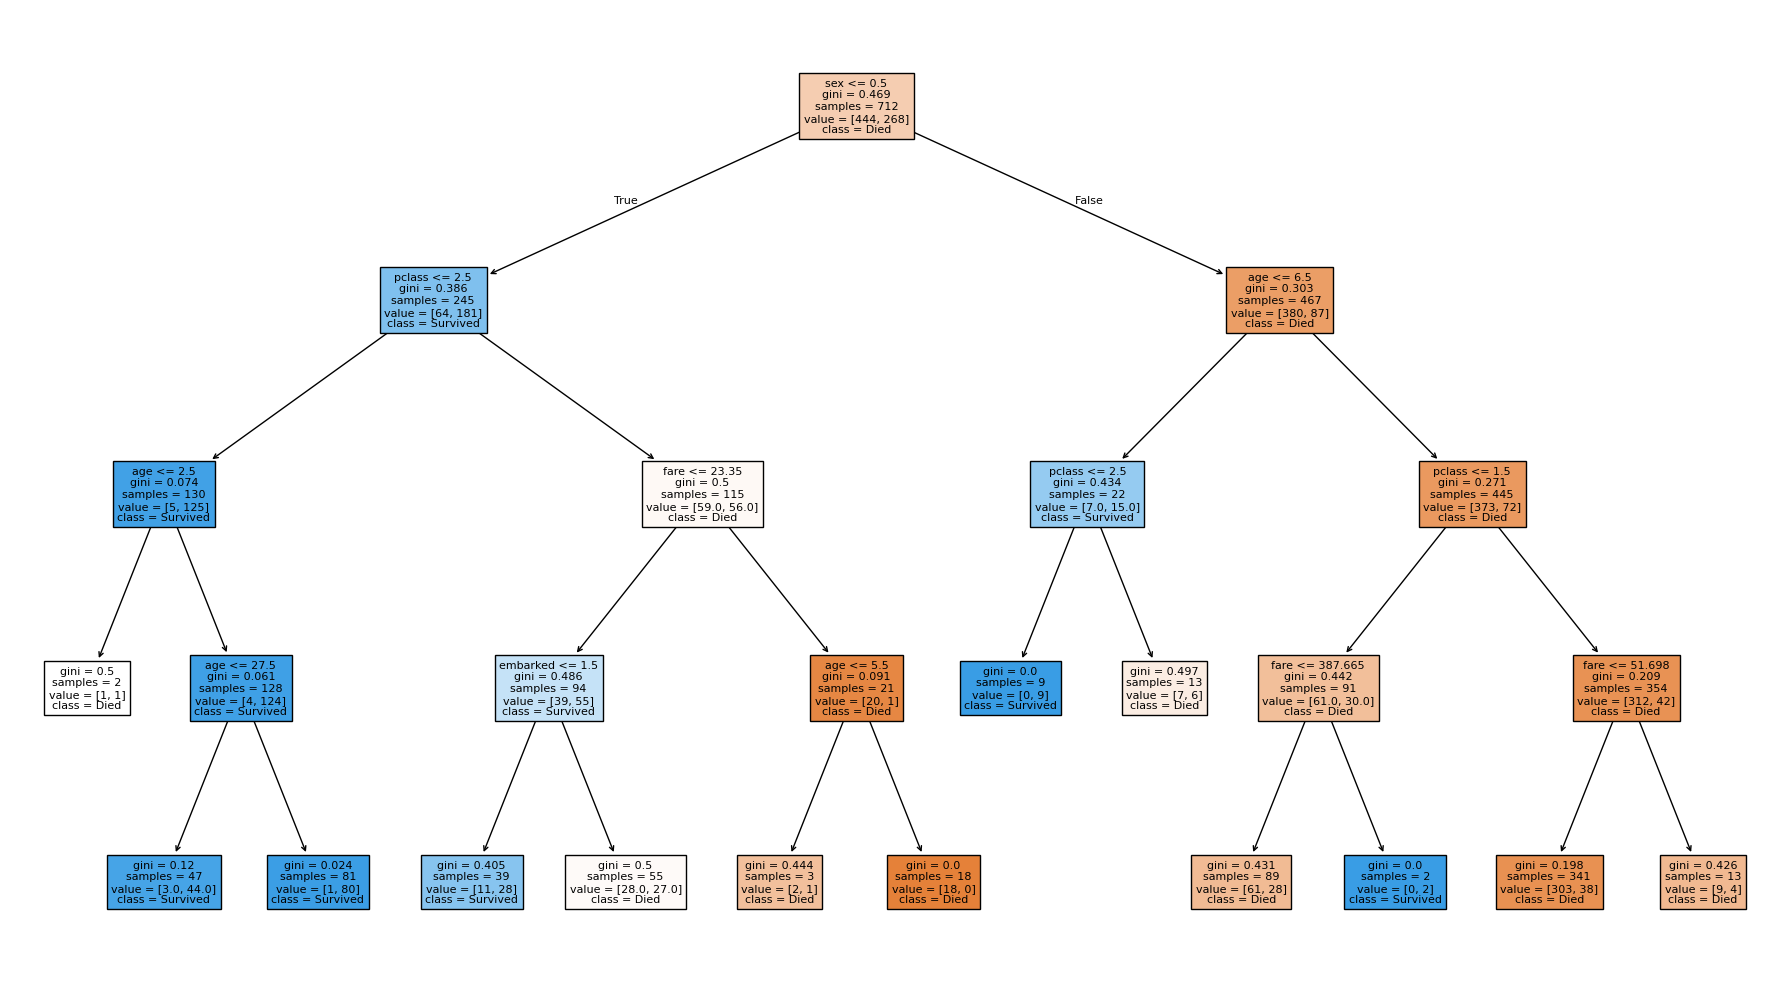

For Min Sample Split = 20, Accuracy = 0.7988826815642458
For Min Sample Split = 25, Accuracy = 0.7932960893854749
For Min Sample Split = 30, Accuracy = 0.7932960893854749


In [61]:
min_samples_split = [10, 15, 20, 25, 30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"For Min Sample Split = {split}, Accuracy = {acc}")

      # Plot only for depth = 9
    if split == 15:
        plt.figure(figsize=(18, 10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )

        plt.tight_layout()
        plt.show()

# DECISION TREE MODEL: POST-PRONING 

In [62]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [65]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [69]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    # acc = model.score(X_test, y_test)

    trees.append((model, alpha))

In [70]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)

    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [72]:
best_alpha

np.float64(0.0)

In [71]:
best_acc

0.7653631284916201

In [73]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0))

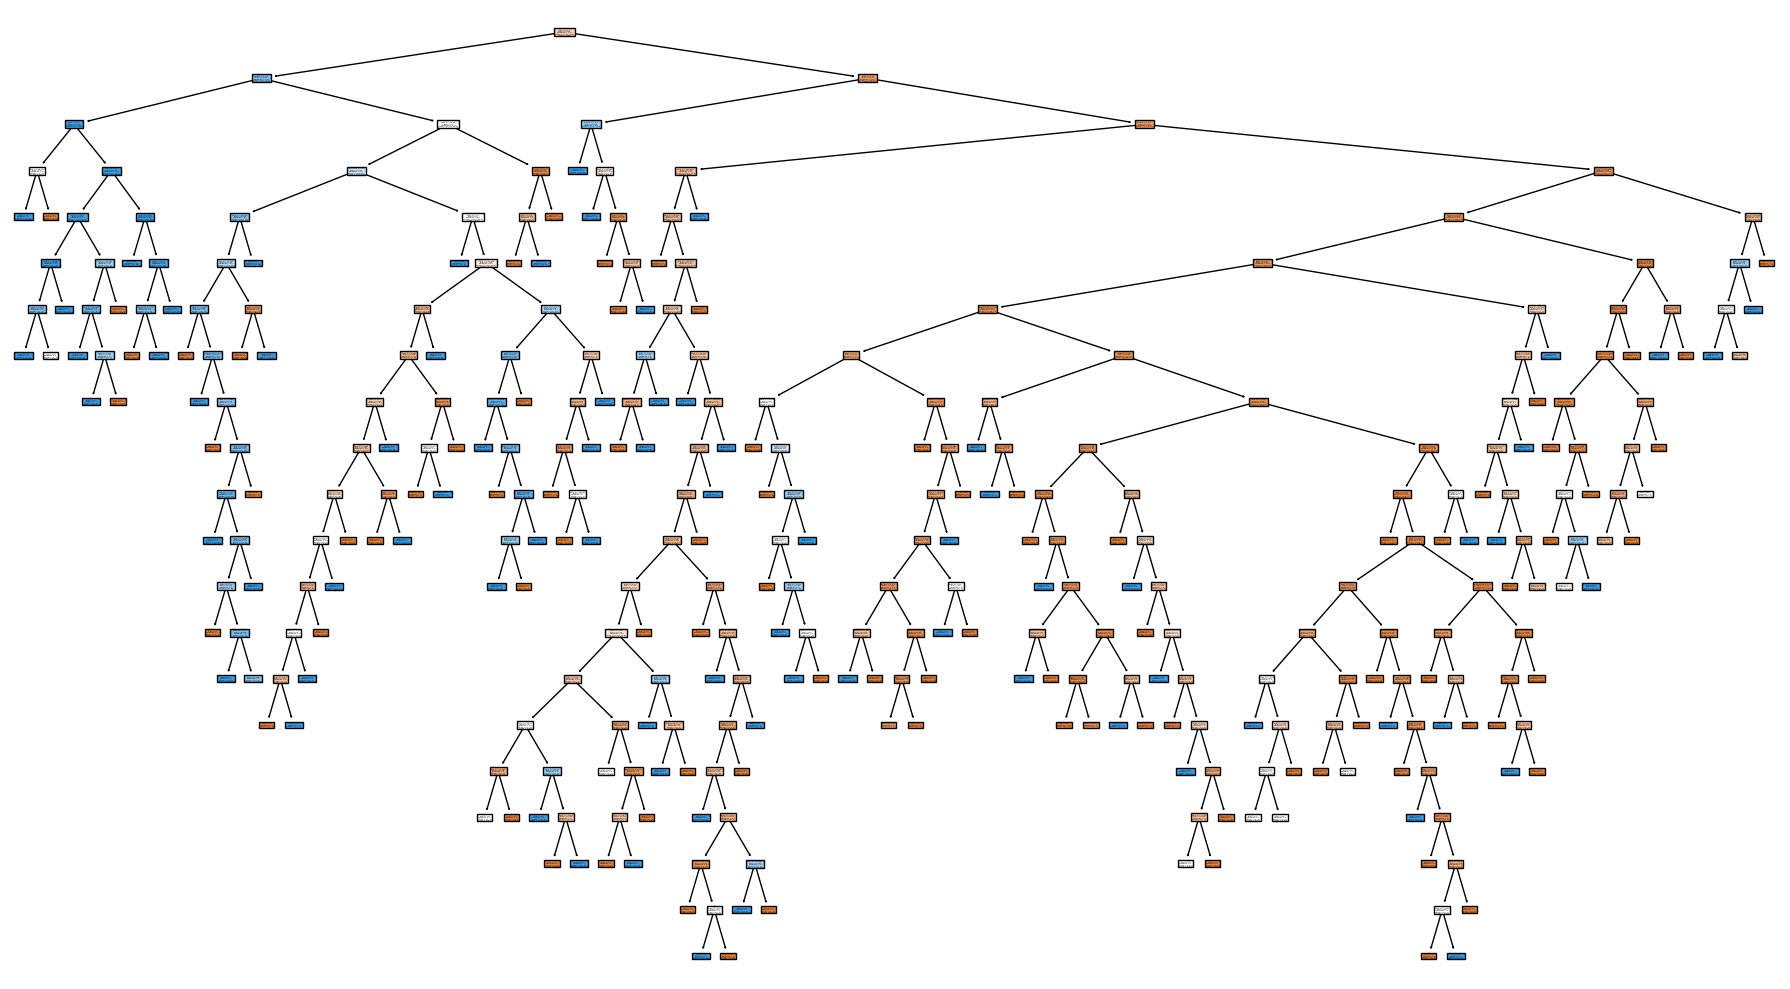

In [74]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survivied"],
    filled=True
)

plt.tight_layout()
plt.show()

In [75]:
best_model.score(X_test, y_test)

0.770949720670391

In [76]:
#BOTH POST PRUNING & PRE-PRONING
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), max_depth=4)

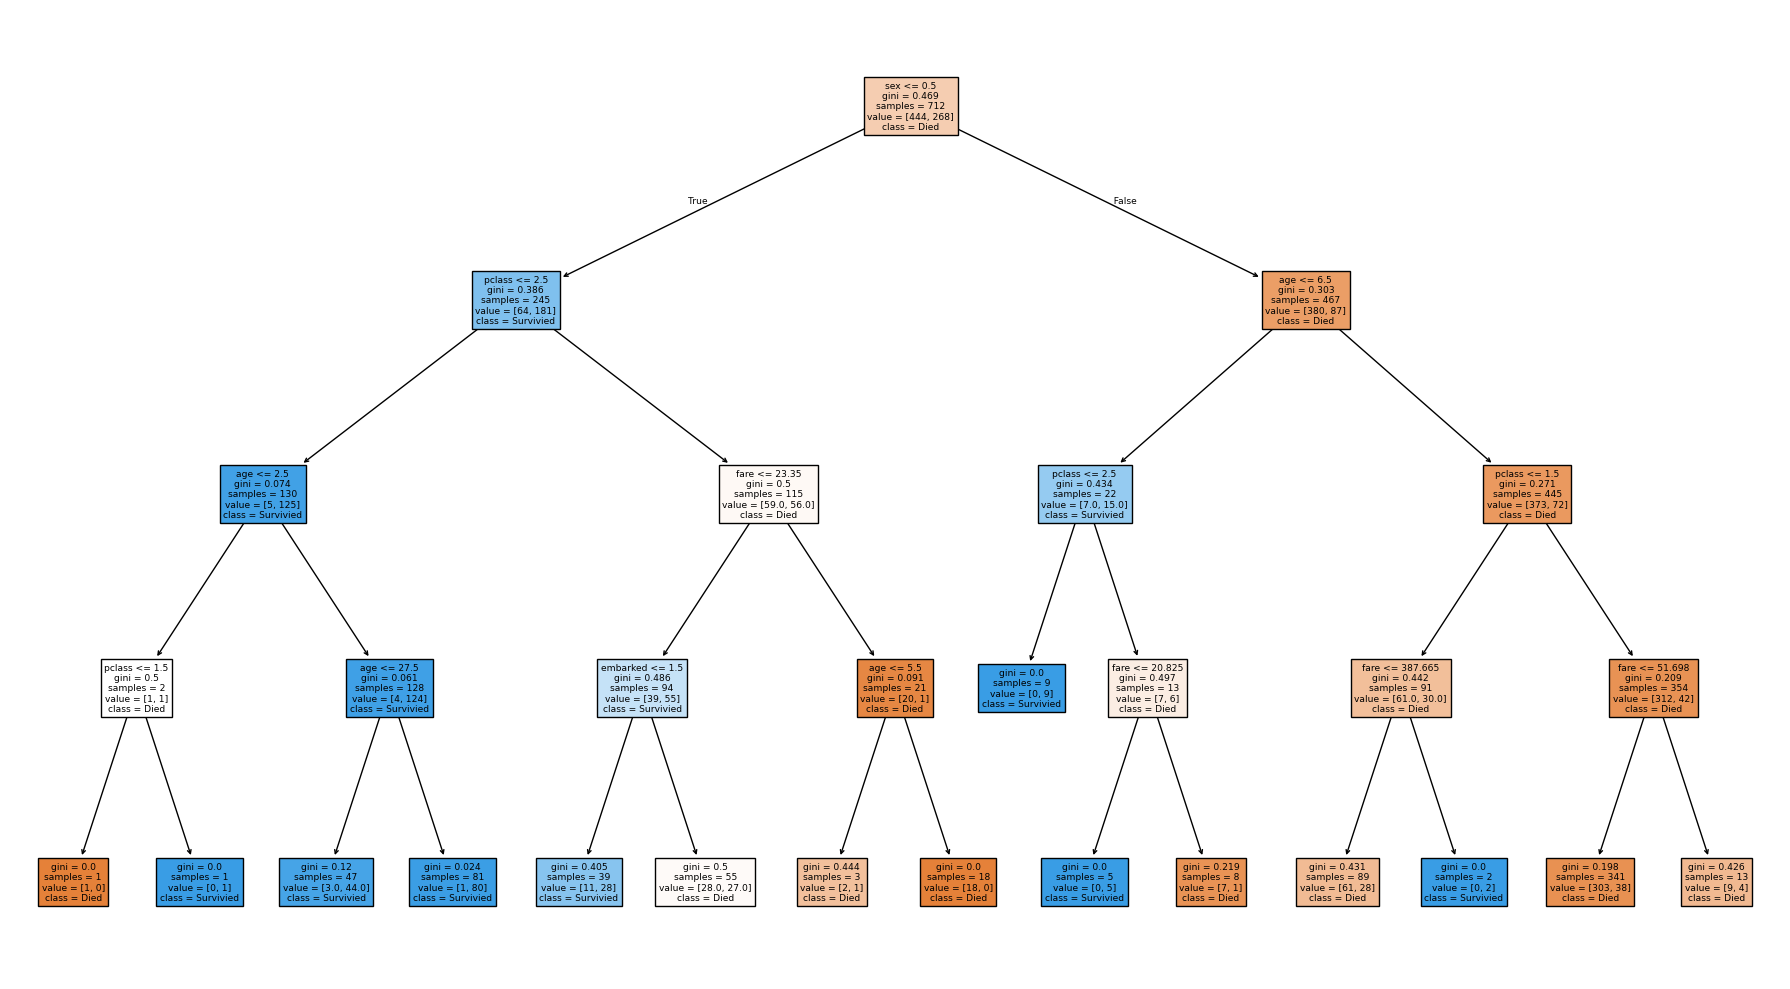

In [77]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survivied"],
    filled=True
)

plt.tight_layout()
plt.show()

In [78]:
best_model.score(X_test, y_test)

0.7988826815642458

In [ ]:
x